# Full Optimization Pipeline on HSCs.

## Prepare the notebook.

### Flags for autoreloading.

In [1]:
AUTORELOAD = True
IS_EXT_LOADED = False

### Optionally autoreload the notebook.

In [2]:
if AUTORELOAD:
    if not IS_EXT_LOADED:
        %load_ext autoreload
        IS_EXT_LOADED = True
    assert IS_EXT_LOADED
    %autoreload 2

### Import libraries.

In [1]:
from collections import defaultdict
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
from scipy.spatial.distance import cdist
from scipy.special import softmax
from scipy.stats import gaussian_kde
from sklearn.neighbors import KernelDensity
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import LabelEncoder
import seaborn as sns
import torch
from tqdm import tqdm
import yaml

from sc_exp_design.constants import DataFields, ParamsFields, PredictionFields
from sc_exp_design.config import NeuralVelocityFieldConfig
from sc_exp_design.metrics import compute_e_distance
from sc_exp_design.models import FlowMatching, TargetPredictionModel
from sc_exp_design.utils import set_reproducibility
from sc_exp_design.training.callbacks import MetricsCallBack, TrainingCallBacks


### Define directories.

In [2]:
BASE_DIR = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/collab-goettgens-SFC"
PERTURBATION_RESPONSE_MODEL_CHECKPOINT_PATH = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/dumps/2025-12-14_11-53-04/cerulean-durian-19_FlowMatching.pkl"
TARGET_PREDICTION_MODEL_CHECKPOINT_PATH = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/dumps/2025-11-14_21-22-45/dashing-frog-1258_TargetPredictionModel.pkl"
PRIOR_FLOW_CHECKPOINT_PATH = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/prior_flow_FlowMatching.pkl"
ANNOTATION_CONFIG_PATH = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/collab-goettgens-SFC/generative_modeling/conditional_flow_matching/config/annotation/default.yaml"


### Define constants.

In [3]:
perturbation_obs_key = "protocol_id"
cell_state_rep = "X_channel_standardized+X_scatter_standardized"

RANDOM_SEED = 42

### Import additional modules.

In [4]:
sys.path.insert(0, f"{BASE_DIR}/inverse/inverse_utils")
sys.path.insert(0, f"{BASE_DIR}/model_utils")
from forward_model import ForwardModel
from lambda_schedulers import schedulers_dict
from loss_guidance import LossGuidedFlow
from z_norm_modules import ZNorm, IZNorm, RescaledTargetPredictionModel


### Read annotation config.

In [5]:
with open(ANNOTATION_CONFIG_PATH, "r") as fb:
    annotation_dict = yaml.safe_load(fb)

### Retrieve scatter features identifiers.

In [6]:
scatter_columns = annotation_dict["scatter_columns"]
n_scatter_feats = len(scatter_columns)
print(f"{n_scatter_feats=}")

n_scatter_feats=6


### Setting seed for reproducibility.

In [7]:
set_reproducibility(RANDOM_SEED)

## Load pretrained models.

### Load cellular response prediction model ($\Phi$).

We will use a pre-trained Conditional Flow Matching model to generate synthetic marker expression and morphological features under distinct medium conditions.

NeuralVelocityField(
  (vf_modules): ModuleDict(
    (x_encoder): MLPBlock(
      (net): Sequential(
        (0): Sequential(
          (0): Linear(in_features=27, out_features=512, bias=True)
          (1): ELU(alpha=1.0)
        )
        (1): Sequential(
          (0): Linear(in_features=512, out_features=512, bias=True)
          (1): ELU(alpha=1.0)
        )
        (2): Sequential(
          (0): Linear(in_features=512, out_features=512, bias=True)
          (1): ELU(alpha=1.0)
        )
        (3): Sequential(
          (0): Linear(in_features=512, out_features=128, bias=True)
          (1): Identity()
        )
      )
    )
    (time_encoder): MLPBlock(
      (net): Sequential(
        (0): Sequential(
          (0): Linear(in_features=256, out_features=2048, bias=True)
          (1): ELU(alpha=1.0)
        )
        (1): Sequential(
          (0): Linear(in_features=2048, out_features=2048, bias=True)
          (1): ELU(alpha=1.0)
        )
        (2): Sequential(
         

(<Figure size 300x300 with 1 Axes>, <Axes: title={'center': 'loss'}>)

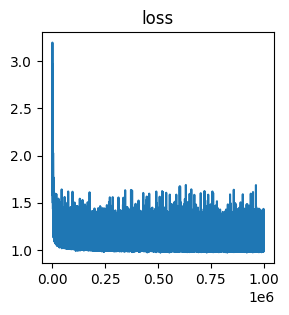

In [8]:
perturbation_response_prediction_model = FlowMatching.load(
    PERTURBATION_RESPONSE_MODEL_CHECKPOINT_PATH
)
print(f"{perturbation_response_prediction_model.velocity_field}")
perturbation_response_prediction_model.trainer.plot_training_logs()

### Load cell type prediction model ($g$).

PerturbationApproximatePosterior(
  (pert_approximate_posterior): ModuleDict(
    (encoder): MLPBlock(
      (net): Sequential(
        (0): Sequential(
          (0): Linear(in_features=27, out_features=2048, bias=True)
          (1): ReLU()
          (2): Dropout(p=0.75, inplace=False)
        )
        (1): Sequential(
          (0): Linear(in_features=2048, out_features=2048, bias=True)
          (1): ReLU()
          (2): Dropout(p=0.75, inplace=False)
        )
        (2): Sequential(
          (0): Linear(in_features=2048, out_features=2048, bias=True)
          (1): ReLU()
          (2): Dropout(p=0.75, inplace=False)
        )
        (3): Sequential(
          (0): Linear(in_features=2048, out_features=8, bias=True)
          (1): Identity()
        )
      )
    )
    (cell_type): MLPBlock(
      (net): Sequential(
        (0): Sequential(
          (0): Linear(in_features=8, out_features=19, bias=True)
          (1): Identity()
        )
      )
    )
  )
)


(<Figure size 300x300 with 1 Axes>, <Axes: title={'center': 'loss'}>)

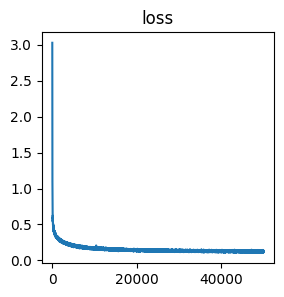

In [9]:
target_prediction_model = TargetPredictionModel.load(
    TARGET_PREDICTION_MODEL_CHECKPOINT_PATH
)
# set label encoder, we are going to need it 
ct_le = LabelEncoder().fit(target_prediction_model.train_data.adata.obs["cell_type"].values)
print(f"{target_prediction_model.target_prediction_model}")

target_prediction_model.target_predictor_trainer.plot_training_logs()

### Load prior flow model $u^\theta_t(\mathbb x, \mathbb e)$.

(<Figure size 300x300 with 1 Axes>, <Axes: title={'center': 'loss'}>)

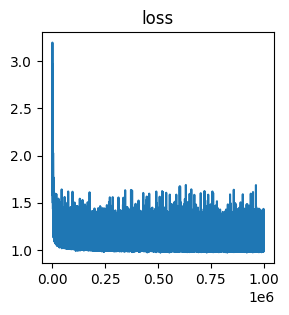

In [10]:
prior_flow = FlowMatching.load(
    PRIOR_FLOW_CHECKPOINT_PATH
)
perturbation_response_prediction_model.trainer.plot_training_logs()

## Prepare reference data.

### Retrieve data for $\Phi$ surrogate.

In [11]:
train_adata_phi = perturbation_response_prediction_model.train_data.adata
val_adata_phi = perturbation_response_prediction_model.validation_data[0].adata
print(f"{train_adata_phi=}\n{val_adata_phi=}")

train_adata_phi=AnnData object with n_obs × n_vars = 92953367 × 21
    obs: 'replicate', 'date', 'cytometer', 'cytometer_serial_no', 'well_id', 'count_beads', 'cell_counts', 'experiment_number', 'experiment_id', '740-yp_[µm]', 'mtg_[µm]', 'rhflt3l_[ng_ml]', 'gm-csf_[ng_ml]', 'tpo_[ng_ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng_ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng_ml]', 'il3_[ng_ml]', 'source_id', 'hydrogel_type', 'o2_[%]', 'source_cell_phenotype', 'total_count_beads', 'counts_source_cell_phenotype', 'days_of_culture', 'plate', 'absolute_number_multiplier_[2^n]', 'cytometer_id', 'FSC - Area', 'FSC - Height', 'FSC - Width', 'SSC - Area', 'SSC - Height', 'SSC - Width', 'Time Stamp', 'batch', 'protocol_id'
    var: 'n', 'channel', 'marker', '$PnD', '$PnB', '$PnR', '$PnG', '$PnE', 'signal_type', 'antibody'
    uns: 'meta', 'processing_steps', 'one_hot', '740-yp_[µm]_one_hot', 'mtg_[µm]_one_hot', 'rhflt3l_[ng_ml]_one_hot', 'gm-csf_[ng_ml]_one_hot', 'tpo_[ng_ml]_

### Retrieve data for $g$ model.

In [12]:
train_adata_g = target_prediction_model.train_data.adata
val_adata_g = target_prediction_model.validation_data.adata
print(f"{train_adata_g=}\n{val_adata_g=}")

train_adata_g=AnnData object with n_obs × n_vars = 70000 × 21
    obs: 'replicate', 'date', 'cytometer', 'cytometer_serial_no', 'well_id', 'count_beads', 'cell_counts', 'experiment_number', 'experiment_id', '740-yp_[µm]', 'mtg_[µm]', 'rhflt3l_[ng_ml]', 'gm-csf_[ng_ml]', 'tpo_[ng_ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng_ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng_ml]', 'il3_[ng_ml]', 'source_id', 'hydrogel_type', 'o2_[%]', 'source_cell_phenotype', 'total_count_beads', 'counts_source_cell_phenotype', 'days_of_culture', 'plate', 'absolute_number_multiplier_[2^n]', 'cytometer_id', 'FSC - Area', 'FSC - Height', 'FSC - Width', 'SSC - Area', 'SSC - Height', 'SSC - Width', 'Time Stamp', 'batch', 'leiden', 'cell_type'
    var: 'n', 'channel', 'marker', '$PnD', '$PnB', '$PnR', '$PnG', '$PnE', 'signal_type', 'antibody'
    uns: 'cell_type_colors', 'leiden', 'leiden_colors', 'meta', 'neighbors', 'processing_steps', 'umap', 'pca', 'X_scatter_params', 'X_channel_params'
   

### Subsampling data for $\Phi$ surrogate.

In [13]:
n_train_cells = 70_000
n_val_cells = 30_000
train_adata_phi = sc.pp.sample(
    train_adata_phi,
    n=n_train_cells,
    copy=True
)
val_adata_phi = sc.pp.sample(
    val_adata_phi,
    n=n_val_cells,
    copy=True
)
print(f"{train_adata_phi=}, {val_adata_phi=}")

train_adata_phi=AnnData object with n_obs × n_vars = 70000 × 21
    obs: 'replicate', 'date', 'cytometer', 'cytometer_serial_no', 'well_id', 'count_beads', 'cell_counts', 'experiment_number', 'experiment_id', '740-yp_[µm]', 'mtg_[µm]', 'rhflt3l_[ng_ml]', 'gm-csf_[ng_ml]', 'tpo_[ng_ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng_ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng_ml]', 'il3_[ng_ml]', 'source_id', 'hydrogel_type', 'o2_[%]', 'source_cell_phenotype', 'total_count_beads', 'counts_source_cell_phenotype', 'days_of_culture', 'plate', 'absolute_number_multiplier_[2^n]', 'cytometer_id', 'FSC - Area', 'FSC - Height', 'FSC - Width', 'SSC - Area', 'SSC - Height', 'SSC - Width', 'Time Stamp', 'batch', 'protocol_id'
    var: 'n', 'channel', 'marker', '$PnD', '$PnB', '$PnR', '$PnG', '$PnE', 'signal_type', 'antibody'
    uns: 'meta', 'processing_steps', 'one_hot', '740-yp_[µm]_one_hot', 'mtg_[µm]_one_hot', 'rhflt3l_[ng_ml]_one_hot', 'gm-csf_[ng_ml]_one_hot', 'tpo_[ng_ml]_one

### Concatenate data and compute emebeddings.

In [ ]:
adata_phi = sc.concat((train_adata_phi, val_adata_phi), uns_merge="same")
sc.pp.pca(adata_phi)
sc.pp.neighbors(adata_phi)
sc.tl.umap(adata_phi)
adata_phi

/home/icb/lorenzo.consoli/miniconda3/envs/sc_exp_design/lib/python3.12/site-packages/numba/np/ufunc/parallel.py:373: NumbaWarning: The TBB threading layer requires TBB version 2021 update 6 or later i.e., TBB_INTERFACE_VERSION >= 12060. Found TBB_INTERFACE_VERSION = 12050. The TBB threading layer is disabled.
  warnings.warn(problem)


## Define rescaling modules.

### Small factory to instantiate rescaling modules.

In [17]:
def get_rescaling(
    adata: sc.AnnData,
    channel_params_key: str = "X_channel_params", 
    scatter_params_key: str = "X_scatter_params",
    inverse: bool = False,
) -> ZNorm | IZNorm:
    X_channel_params_fwd = adata.uns[channel_params_key]
    X_scatter_params_fwd = adata.uns[scatter_params_key]
    params = {
        ParamsFields.MEAN: torch.from_numpy(
            np.concatenate(
                (
                    X_channel_params_fwd[ParamsFields.MEAN],
                    X_scatter_params_fwd[ParamsFields.MEAN]
                ), axis=0
            )
        ),
        ParamsFields.COVARIANCE: torch.from_numpy(
            np.concatenate(
                (
                    X_channel_params_fwd["std"],
                    X_scatter_params_fwd["std"]
                ), axis=0
            )
        ),
    }
    if inverse:
        return IZNorm(params)
    return ZNorm(params)

### Get Transformations from Cellular response prediction model.

In [18]:
z_norm_phi = get_rescaling(train_adata_phi)
iz_norm_phi = get_rescaling(
    train_adata_phi,
    inverse=True
)
print(f"{z_norm_phi=}\n {iz_norm_phi=}")


z_norm_phi=ZNorm(
  (params): ModuleDict(
    (mean): ModelParam()
    (covariance): ModelParam()
  )
)
 iz_norm_phi=IZNorm(
  (params): ModuleDict(
    (mean): ModelParam()
    (covariance): ModelParam()
  )
)


### Get Transformation from Cell Type Classifier.

In [19]:
z_norm_g = get_rescaling(train_adata_g)
iz_norm_g = get_rescaling(
    train_adata_g,
    inverse=True
)
print(f"{z_norm_g=}\n {iz_norm_g=}")


z_norm_g=ZNorm(
  (params): ModuleDict(
    (mean): ModelParam()
    (covariance): ModelParam()
  )
)
 iz_norm_g=IZNorm(
  (params): ModuleDict(
    (mean): ModelParam()
    (covariance): ModelParam()
  )
)


## Forward Model.

### Initialize rescaled target prediction model.

In [20]:
g_model = RescaledTargetPredictionModel(
    target_prediction_model.target_prediction_model,
    inv_params=iz_norm_phi,
    fwd_params=z_norm_g,
)
g_model

RescaledTargetPredictionModel(
  (resc_model): ModuleDict(
    (inv_params): IZNorm(
      (params): ModuleDict(
        (mean): ModelParam()
        (covariance): ModelParam()
      )
    )
    (fwd_params): ZNorm(
      (params): ModuleDict(
        (mean): ModelParam()
        (covariance): ModelParam()
      )
    )
    (model): PerturbationApproximatePosterior(
      (pert_approximate_posterior): ModuleDict(
        (encoder): MLPBlock(
          (net): Sequential(
            (0): Sequential(
              (0): Linear(in_features=27, out_features=2048, bias=True)
              (1): ReLU()
              (2): Dropout(p=0.75, inplace=False)
            )
            (1): Sequential(
              (0): Linear(in_features=2048, out_features=2048, bias=True)
              (1): ReLU()
              (2): Dropout(p=0.75, inplace=False)
            )
            (2): Sequential(
              (0): Linear(in_features=2048, out_features=2048, bias=True)
              (1): ReLU()
            

### Initialize Forward Model.

In [21]:
forward_model = ForwardModel(
    forward_model=perturbation_response_prediction_model,
    target_prediction_model=g_model,
)
forward_model

## Predict cell type on full data.

### Forward pass on the model.

In [22]:
X_train = torch.from_numpy(train_adata_phi.obsm[cell_state_rep]).float().cuda()
X_val = torch.from_numpy(val_adata_phi.obsm[cell_state_rep]).float().cuda()

g_model.eval()
with torch.no_grad():
    G_logits_train = g_model(
        X_train
    )["cell_type"].detach().cpu().numpy()
    G_logits_val = g_model(
        X_val
    )["cell_type"].detach().cpu().numpy()

### Post process output.

In [23]:
G_probs_train = softmax(G_logits_train, axis=1)
G_probs_val = softmax(G_logits_val, axis=1)

G_id_train = G_probs_train.argmax(1)
G_id_val = G_probs_val.argmax(1)

G_label_train = ct_le.inverse_transform(G_id_train)
G_label_val = ct_le.inverse_transform(G_id_val)
print(f"{G_logits_train.shape=}, {G_logits_val.shape=}, {G_probs_train.shape=}, {G_probs_val.shape=}, {G_id_train.shape=}, {G_id_val.shape=}, {G_label_train.shape=}, {G_label_val.shape=}")


G_logits_train.shape=(70000, 19), G_logits_val.shape=(30000, 19), G_probs_train.shape=(70000, 19), G_probs_val.shape=(30000, 19), G_id_train.shape=(70000,), G_id_val.shape=(30000,), G_label_train.shape=(70000,), G_label_val.shape=(30000,)


#### Plot proportion of predicted cell types.

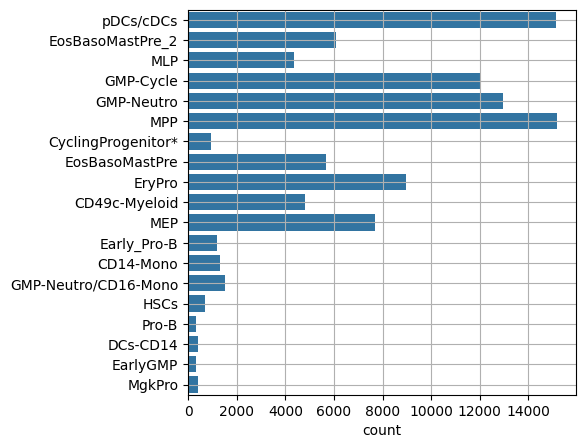

In [24]:
plt.figure(figsize=(5,5))
sns.countplot(np.concatenate((G_label_train, G_label_val), axis=0))
plt.grid(1)

## Posterior Sampling.

### Class for penalty-constrained loss guided flows.

In [25]:
# AAA
from functools import partial

from sc_exp_design.utils import match_shapes
from torchdiffeq import odeint

class PenalisedLossGuidedFlow(LossGuidedFlow):
    """
    Guided flow with exponential upper-bound penalty on the one-step prediction.
    """

    def __init__(self, prior_flow, forward_model, loss_fn, ubound, lbound, cmask=None,
                 fix_noise=True,# aggregate_phenotype_per_sample=True, 
                 n_time_steps_forward_model=100,
                 solver_kwargs_forward_model={"method":"euler"},
                 num_forward_pass_per_sample=1000, condition_key="repr_condition_conditions",
                 device_id="cuda", beta=1.5, c_scheduler=lambda t: torch.ones_like(t)):
        super().__init__(prior_flow, forward_model, loss_fn,
                         fix_noise=fix_noise, solver_kwargs_forward_model=solver_kwargs_forward_model,
                         n_time_steps_forward_model=n_time_steps_forward_model,
                        #  aggregate_phenotype_per_sample=aggregate_phenotype_per_sample,
                         num_forward_pass_per_sample=num_forward_pass_per_sample,
                        #  condition_key=condition_key,
                        #  device_id=device_id
                         )
        self.cmask = slice(None) if cmask is None else cmask
        self.ubound = torch.tensor(ubound, dtype=torch.float32, device=device_id)
        self.lbound = torch.tensor(lbound, dtype=torch.float32, device=device_id)
        self.beta = beta  # sharpness of exponential penalty
        self.c_scheduler = c_scheduler        # scaling coefficient for constraint

    def compute_upper_bound_penalty(self, t, xt):
        """
        Computes the gradient of the exponential penalty for exceeding the upper bound.
        Uses one-step prediction x_next = x_t + (1-t)*v(x_t)
        """
        xt = xt.clone().detach().requires_grad_(True)
        x_next = self.compute_one_step_prediction(t, xt)

        # Exponential penalty
        r = x_next - self.ubound
        penalty = torch.sum(torch.expm1(self.beta * torch.relu(r))[..., self.cmask])  # sum over features
        grad_xt = torch.autograd.grad(penalty, xt, retain_graph=True)[0]
        return self.c_scheduler(t) * grad_xt

    def compute_lower_bound_penalty(self, t, xt):
        """
        Computes the gradient of the exponential penalty for exceeding the upper bound.
        Uses one-step prediction x_next = x_t + (1-t)*v(x_t)
        """
        xt = xt.clone().detach().requires_grad_(True)
        x_next = self.compute_one_step_prediction(t, xt)

        # Exponential penalty
        r = self.lbound - x_next
        penalty = torch.sum(torch.expm1(self.beta * torch.relu(r))[..., self.cmask])  # sum over features
        grad_xt = torch.autograd.grad(penalty, xt, retain_graph=True)[0]
        return self.c_scheduler(t) * grad_xt

    def guided_vf_fn(self, t, xt, optimal_condition=None,
                     lambda_scheduler  = None,
                     non_linearity=None, noise=None, **kwargs):
        """
        Guided velocity field for ODE integration
        """
        t = match_shapes(t, xt)

        # Base velocity field
        vf_fn = self.prior_flow.velocity_field.get_vf_fn()
        vt = vf_fn(t[:, 0], xt)

        # Loss-guided term
        loss, gt = self.compute_loss_gradients(t, xt, optimal_condition, non_linearity, noise=noise)
        self._loss_history.append(loss)

        # Optional decay via lambda scheduler
        guidance_strength = 1.0
        if lambda_scheduler is not None:
            L0 = self._loss_history[0].unsqueeze(1)
            guidance_strength = lambda_scheduler.compute_lambda_t(t, xt, vt, gt, optimal_condition, L0, loss, **kwargs)
        self._lambda_history.append(guidance_strength)

        # Exponential upper-bound penalty
        grad_upper = self.compute_upper_bound_penalty(t, xt)
        grad_lower = self.compute_lower_bound_penalty(t, xt)

        # Corrected velocity
        vt_corrected = vt - guidance_strength * (gt + grad_upper + grad_lower)
        return vt_corrected

    def sample_posterior(self, N, optimal_condition,
                         num_time_steps=50, solver_kwargs=None,
                         lambda_scheduler = None,
                         return_loss=True, return_lambdas=True,
                         non_linearity=None, **kwargs):
        # Initialize histories
        self._loss_history = []
        self._lambda_history = []

        if solver_kwargs is None:
            solver_kwargs = {"method": "euler", "atol": 1e-5, "rtol": 1e-5}

        time = torch.linspace(0.0, 1.0, num_time_steps)
        source = torch.randn((N, self.prior_flow.cvf_config.flow_dim), device=self.prior_flow.device_id)

        # Sampling fixed noise for the forward model
        if self.fix_noise:
            noise = self.forward_model.forward_model.noise_distribution(
                (N, self.num_forward_pass_per_sample, self.forward_model.forward_model.velocity_field.config.flow_dim)
            ).squeeze(dim=0).to(self.forward_model.forward_model.device)
        else:
            noise = None

        # Partial function for odeint
        vf_fn = partial(
            self.guided_vf_fn,
            optimal_condition=optimal_condition,
            lambda_scheduler=lambda_scheduler,
            non_linearity=non_linearity,
            noise=noise,
            **kwargs
        )

        # Integrate ODE
        traj = odeint(vf_fn, source, time, **solver_kwargs).detach().cpu().numpy()

        # Return histories
        results = [noise]
        if return_loss:
            loss_history = torch.stack(self._loss_history, dim=0).detach().cpu().numpy()
            results.append(loss_history.T)
        if return_lambdas:
            lambda_history = torch.stack(self._lambda_history, dim=0).squeeze().detach().cpu().numpy()
            results.append(lambda_history.T)
        return (traj, *results) if results else traj


### Define settings.

In [26]:
solver_kwargs_forward_model = {"method": "euler"}
loss_fns = {
"cell_type": lambda pred, target:
    -torch.sum(
        target*torch.nn.functional.log_softmax(pred, dim=-1),
        dim=-1
    )
}


### Prepare constraints.

In [27]:
sys.path.insert(0, "../../../scripts")
from data_utils import get_protocol_tranformations

# read columns
protocol_columns = annotation_dict["protocol_columns"]
log1p_exp_cols = annotation_dict["log1p_exp_cols"]
log21p_exp_cols = annotation_dict["log21p_exp_cols"]

# transformations
ptransf = get_protocol_tranformations(
    protocol_columns,
    log1p_exp_cols=log1p_exp_cols,
    log21p_exp_cols=log21p_exp_cols,
    inverse=False
)

# define upper bound
def map_df(df, transforms_dict):
    transformed_data_df = {}
    for mol in df.columns:
        trnsf = transforms_dict[mol]
        val = df.loc[:, mol].values
        if trnsf is not None:
            val = trnsf(val)
        transformed_data_df[mol] = val
    return pd.DataFrame(transformed_data_df, index=df.index)

ubound_df = pd.DataFrame({
    "o2_[%]": np.array([21.0]),
    "days_of_culture": np.array([21]),
}); ubound_df = map_df(ubound_df, ptransf)
lbound_df = pd.DataFrame({
    "o2_[%]": np.array([20.0]),
    "days_of_culture": np.array([14]),
}); lbound_df = map_df(lbound_df, ptransf)
# map_df(ubound, ptransf)\

# create mask for constraints
cmask = [protocol_columns.index(k) for k in ubound_df.columns]

# fill remaning values
lbound = torch.zeros(len(protocol_columns))
for k in lbound_df.columns:
    idx = protocol_columns.index(k)
    lbound[idx] = lbound_df[k].item()
ubound = torch.zeros(len(protocol_columns))
for k in ubound_df.columns:
    idx = protocol_columns.index(k)
    ubound[idx] = ubound_df[k].item()
print(lbound)
print(ubound)

tensor([0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 3.0445, 2.7081])
tensor([0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 3.0910, 3.0910])


### Initialize guided flow.

In [28]:
import math
def lin_c_scheduler(t, lmin=0.0, lmax=10.0, gamma=2.0):
    return lmin + (lmax - lmin)*t

def exp_c_scheduler(t, lmin=0.0, lmax=10.0, gamma=2.0):
    b = (lmin - lmax)/(math.exp(-gamma)-1)
    a = lmax - b
    return a + b*torch.exp(-gamma*(1 - t))

use_exp = False
use_scheduler = True

c_scheduler = lin_c_scheduler
if use_exp: c_scheduler = exp_c_scheduler
if not use_scheduler:
    c_scheduler = lambda t: torch.ones_like(t)


n_fwd_samples = 500
n_time_steps_forward_model = 10
beta = 1.5

guided_flow = PenalisedLossGuidedFlow(
    prior_flow,
    forward_model,
    loss_fns,
    ubound, lbound, cmask=cmask,
    fix_noise=True,
    num_forward_pass_per_sample=n_fwd_samples,
    n_time_steps_forward_model=n_time_steps_forward_model,
    solver_kwargs_forward_model=solver_kwargs_forward_model,
    beta=beta,
    c_scheduler=c_scheduler
)
non_linearity = torch.nn.ReLU()

/tmp/ipykernel_3581558/1996580009.py:27: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.ubound = torch.tensor(ubound, dtype=torch.float32, device=device_id)
/tmp/ipykernel_3581558/1996580009.py:28: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.lbound = torch.tensor(lbound, dtype=torch.float32, device=device_id)


### Initialize scheduler.

In [29]:
scheduler_id = "reciprocal"
lmax = 5.0
lmin = 0.0
gamma = 5.5
scheduler = schedulers_dict[scheduler_id](lmax=lmax, lmin=lmin, gamma=gamma)
scheduler

### Visualize schedule.

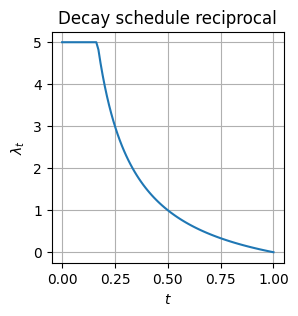

In [30]:
# visualizing decaying scheduler
t = torch.linspace(0.0, 1.0, 100)
lambda_t = scheduler.compute_lambda_t(t)
plt.figure(figsize=(3, 3))
plt.plot(t, lambda_t)
plt.title(fr"Decay schedule {scheduler_id}")
plt.xlabel(r"$t$")
plt.ylabel(r"$\lambda_t$")
plt.grid(True)

### Define Target.

In [31]:
target_cell_type = "MgkPro"
classes = ct_le.classes_.tolist()
n_classes = len(classes)

idx = classes.index(target_cell_type)
target = torch.zeros((n_classes,)).float().to(forward_model.forward_model.device)
target[idx] = 1.0
target = {
    "cell_type": target.unsqueeze(0)
}
target

{'cell_type': tensor([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0.,
          0.]], device='cuda:0')}

### Sampling from inverse model.

In [32]:
use_sde = False
n_samples = 150
n_time_steps = 30 if use_sde else 100
solver_kwargs = {"method": "euler", "atol": 1e-5, "rtol": 1e-5, }
# solver_kwargs = {"method": "dopri5", "atol": 1e-5, "rtol": 1e-5, "options":{"dtype": torch.float32}}
seed = 42
set_reproducibility(seed)

torch.cuda.empty_cache()
traj, noise, loss_history, lambda_history = guided_flow.sample_posterior(
    n_samples,
    optimal_condition=target,
    num_time_steps=n_time_steps,
    solver_kwargs=solver_kwargs,
    lambda_scheduler=scheduler,
    non_linearity=non_linearity,
    sde_sampling=use_sde,
    scheduler=scheduler,
)

torch.cuda.empty_cache()
# print(f"{traj.shape=}, {loss_history.shape=}, {lambda_history.shape=}, {noise.shape=}")

/home/icb/lorenzo.consoli/miniconda3/envs/sc_exp_design/lib/python3.12/site-packages/torchdiffeq/_impl/misc.py:306: UserWarning: t is not on the same device as y0. Coercing to y0.device.
  warnings.warn("t is not on the same device as y0. Coercing to y0.device.")


## Query Forward model with samples. 

### Call forward model.

In [33]:
samples = np.maximum(traj[-1], 0)
perturbation_reps = next(iter(perturbation_response_prediction_model.train_data.data.perturbation_covariates))
ccondition_data = torch.from_numpy(samples).float().to(perturbation_response_prediction_model.device)
ccondition_dict = {
    perturbation_reps: ccondition_data.unsqueeze(1).repeat(1, n_fwd_samples, 1),
}

batch_dict = {
    DataFields.PERTURBATION_DATA: ccondition_dict,
    DataFields.SOURCE_STATE: noise
}

num_time_steps = 100
cforward_out = forward_model.predict(
    batch_dict,
    return_trajectory=False,
    no_grad=True,
    num_time_steps=num_time_steps,
    solver_kwargs=solver_kwargs,
    fix_noise=True,
)

### Post-process output.

In [34]:
X_gen = cforward_out[PredictionFields.PREDICTION_DATA].detach().cpu().numpy()
gen_ct_logits = cforward_out[PredictionFields.TARGET_PREDICTION_DATA]["cell_type"].detach().cpu().numpy()

X_channel_gen = X_gen[..., :-n_scatter_feats]
X_scatter_gen = X_gen[..., -n_scatter_feats:]

gen_ct_probs = softmax(gen_ct_logits, axis=-1)
gen_ct_id_label = gen_ct_probs.argmax(-1)
gen_ct_label = ct_le.inverse_transform(gen_ct_id_label.reshape(-1)).\
    reshape(gen_ct_id_label.shape[0], gen_ct_id_label.shape[1])
print(f"{X_gen.shape=}, {X_channel_gen.shape=}, {X_scatter_gen.shape=}, {gen_ct_logits.shape=} {gen_ct_id_label.shape=}, {gen_ct_label.shape=}")


X_gen.shape=(150, 500, 27), X_channel_gen.shape=(150, 500, 21), X_scatter_gen.shape=(150, 500, 6), gen_ct_logits.shape=(150, 500, 19) gen_ct_id_label.shape=(150, 500), gen_ct_label.shape=(150, 500)


### Plot loss history.

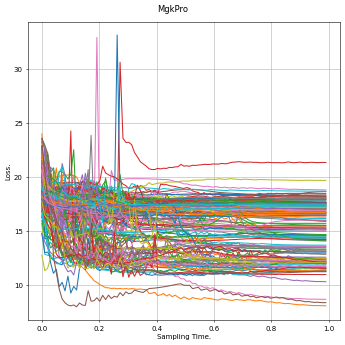

In [35]:
fig, ax = plt.subplots(figsize=(7, 7), dpi=50)
t = np.arange(0, 1, 1/loss_history.shape[1])
lines = ax.plot(t, loss_history.T)
fig.suptitle(f"{target_cell_type}")
ax.set_xlabel("Sampling Time.")
ax.set_ylabel("Loss.")
ax.grid(1)
fig.tight_layout(); fig.show()

## Visualize condition covariates.

### Displaying condition samples heatmap.

<Axes: >

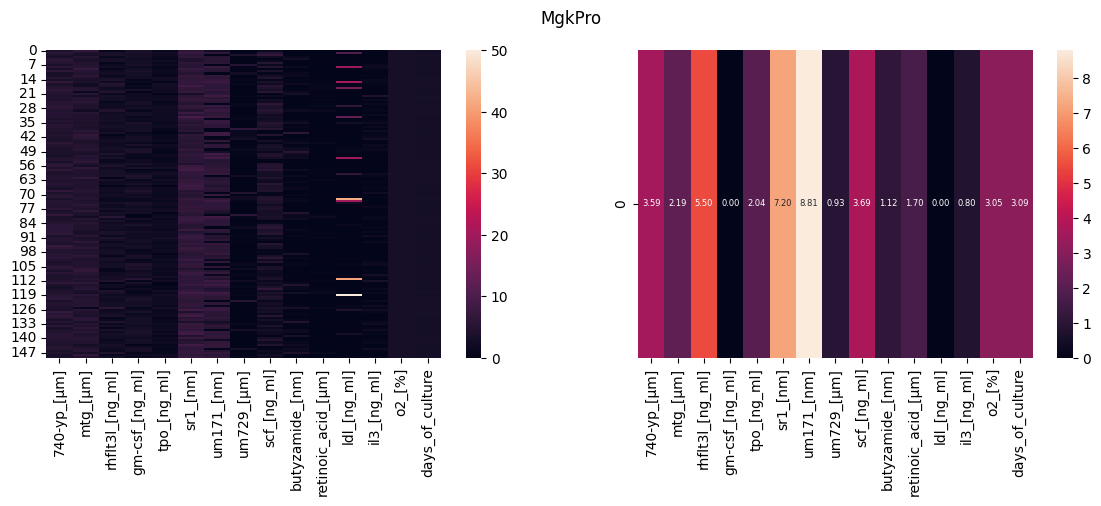

In [36]:
emin_loss_idx = np.argmin(loss_history[:, -1])
samples = np.maximum(traj[-1], 0)
fig, ax = plt.subplots(1, 2, figsize=(14, 4), dpi=100)
fig.suptitle(target_cell_type)
sns.heatmap(samples, annot=False, ax=ax[0], xticklabels=annotation_dict["protocol_columns"])
sns.heatmap(samples[emin_loss_idx][None], annot=True, ax=ax[1], xticklabels=annotation_dict["protocol_columns"], fmt=".2f", annot_kws={"size": 6})

### Hierachical cluster of the samples.

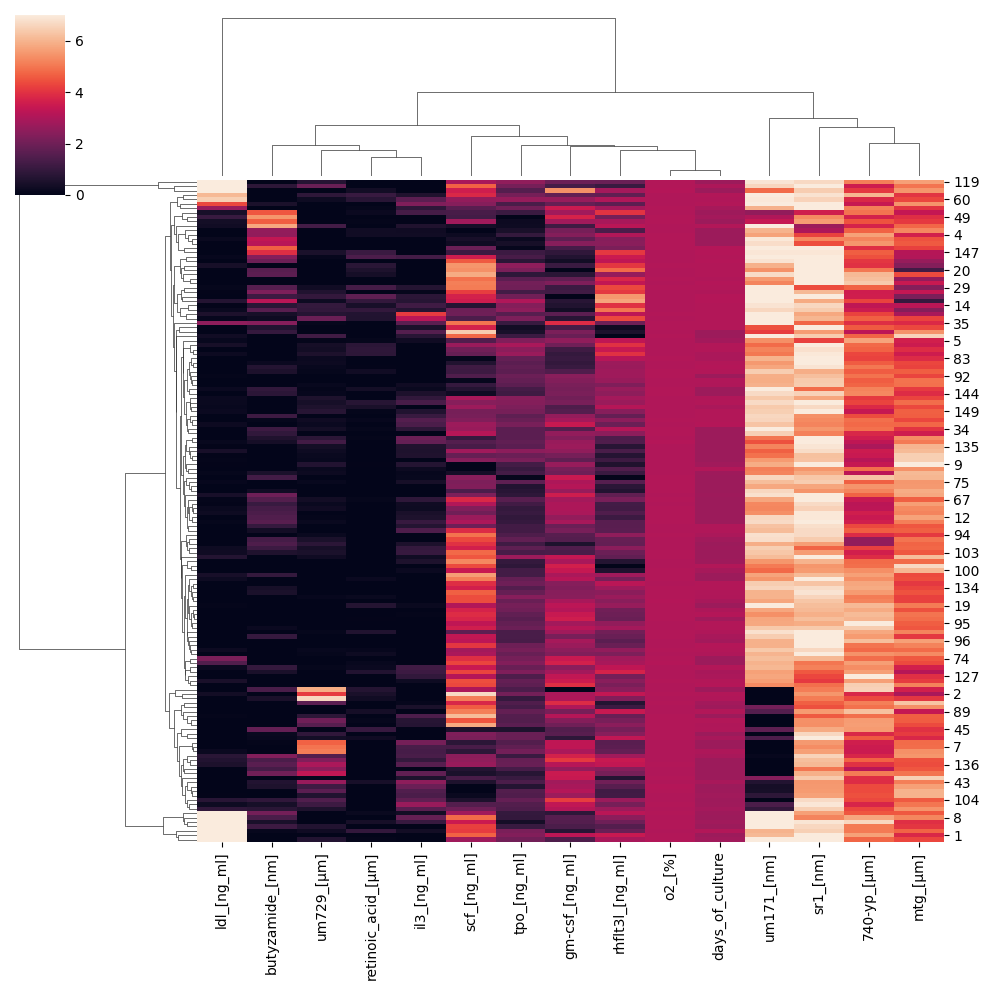

In [37]:
emin_loss_idx = np.argmin(loss_history[:, -1])
samples = np.maximum(traj[-1], 0)
sns.clustermap(samples, annot=False, xticklabels=annotation_dict["protocol_columns"], vmin=0.0, vmax=7.0)

## Visualize sampled condition in the learned embedding space.

### Retrieve learned embeddings.

In [38]:
ccond_emb = perturbation_response_prediction_model.velocity_field.get_condition_embedding(ccondition_dict)[:, 0]
ccond_emb.shape

torch.Size([150, 512])

### Sampling random projection matrices.

In [39]:
n_projections = 100000
sigma = 0.1
projections = torch.randn((n_projections, ccond_emb.shape[1], 2)).float().cuda() * sigma
print(f"{projections.shape=}")

projections.shape=torch.Size([100000, 512, 2])


### Project and average conditions.

In [40]:
projected_conds_gen = torch.einsum("nd,mdp->nmp", ccond_emb, projections).mean(1).detach().cpu().numpy()
print(f"{projected_conds_gen.shape=}")

projected_conds_gen.shape=(150, 2)


### Retrieve unique condition values from train and validation.

In [41]:
unique_train_conds = np.unique(
    train_adata_phi.obsm["condition_concat"], axis=0
)
unique_val_conds = np.unique(
    val_adata_phi.obsm["condition_concat"], axis=0
)
print(f"{unique_train_conds.shape=}, {unique_val_conds.shape=}")

unique_train_conds.shape=(115, 15), unique_val_conds.shape=(1, 15)


### Constructing condition dictionaries.

In [42]:
train_cond_dict = {
    perturbation_reps: torch.from_numpy(unique_train_conds).float().cuda()
}
val_cond_dict = {
    perturbation_reps: torch.from_numpy(unique_val_conds).float().cuda()
}

### Forward pass on condition encoder.

In [43]:
train_cond_emb = perturbation_response_prediction_model.velocity_field.get_condition_embedding(train_cond_dict)
val_cond_emb = perturbation_response_prediction_model.velocity_field.get_condition_embedding(val_cond_dict)
train_cond_emb.shape, train_cond_emb.shape

(torch.Size([115, 512]), torch.Size([115, 512]))

### Projecting real conditions.

In [44]:
projected_conds_train = torch.einsum("nd,mdp->nmp", train_cond_emb, projections).mean(1).detach().cpu().numpy()
projected_conds_val = torch.einsum("nd,mdp->nmp", val_cond_emb, projections).mean(1).detach().cpu().numpy()
print(f"{projected_conds_train.shape=}, {projected_conds_val.shape}")

projected_conds_train.shape=(115, 2), (1, 2)


### Visualize projections.

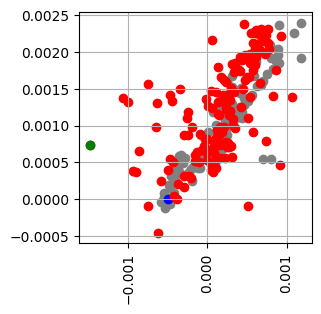

In [45]:
fig, ax = plt.subplots(figsize=(3, 3))
ax.scatter(
    projected_conds_train[:, 0],
    projected_conds_train[:, 1],
    label="train",
    color="grey",
)
ax.scatter(
    projected_conds_val[:, 0],
    projected_conds_val[:, 1],
    label="val",
    color="blue",
)
ax.scatter(
    projected_conds_gen[:, 0],
    projected_conds_gen[:, 1],
    label="val",
    color="red",
)
ax.scatter(
    projected_conds_gen[emin_loss_idx, 0][None],
    projected_conds_gen[emin_loss_idx, 1][None],
    label="val",
    color="green",
)
ax.grid(True)
ax.tick_params("x", rotation=90)

### Compute (L2) distance from real data in embedding space.

In [46]:
D_espace_learned = cdist(ccond_emb.detach().cpu().numpy(), np.concatenate((train_cond_emb.detach().cpu().numpy(), val_cond_emb.detach().cpu().numpy()), axis=0))
D_espace_learned.shape

(150, 116)

### Distribution of mean distance.

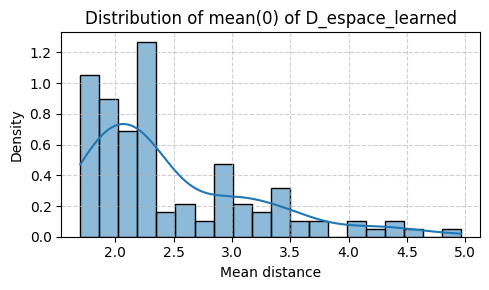

In [47]:
plt.figure(figsize=(5, 3))
sns.histplot(D_espace_learned.mean(0), bins=20, kde=True, stat="density")
plt.grid(True, linestyle="--", alpha=0.6)
plt.xlabel("Mean distance")
plt.ylabel("Density")
plt.title("Distribution of mean(0) of D_espace_learned")
plt.tight_layout()
plt.show()

### Retrieve closest neighbor in embedding space for best sample.

In [48]:
min_dist_idx = D_espace_learned[emin_loss_idx].argsort()[0].item()
nn_real_cond_best = unique_train_conds[min_dist_idx]

### Heatmap of NN condition.

<Axes: >

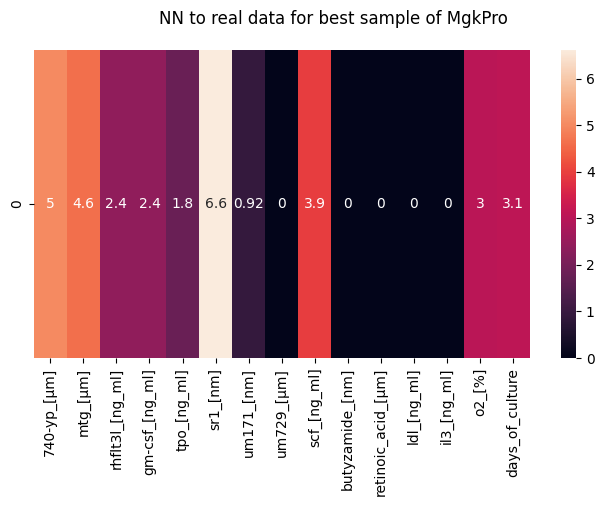

In [49]:
emin_loss_idx = np.argmin(loss_history[:, -1])
samples = np.maximum(traj[-1], 0)
fig, ax = plt.subplots(figsize=(8, 4), dpi=100)
fig.suptitle(f"NN to real data for best sample of {target_cell_type}")
sns.heatmap(nn_real_cond_best[None], annot=True, ax=ax, xticklabels=annotation_dict["protocol_columns"])

## Visualize sampled condition in the original concentration space.

### Sample random projection matrix.

In [50]:
n_projections = 100000
sigma = 0.1 
projections = torch.randn((n_projections, samples.shape[1], 2)).float().cuda() * sigma
print(f"{projections.shape=}")


projections.shape=torch.Size([100000, 15, 2])


### Project and average.

In [51]:
projected_conds_gen = torch.einsum("nd,mdp->nmp", torch.from_numpy(samples).float().cuda(), projections).mean(1).detach().cpu().numpy()
projected_conds_train = torch.einsum("nd,mdp->nmp", torch.from_numpy(unique_train_conds).float().cuda(), projections).mean(1).detach().cpu().numpy()
projected_conds_val = torch.einsum("nd,mdp->nmp", torch.from_numpy(unique_val_conds).float().cuda(), projections).mean(1).detach().cpu().numpy()
print(f"{projected_conds_train.shape=}, {projected_conds_val.shape}, {projected_conds_gen.shape=}")

projected_conds_train.shape=(115, 2), (1, 2), projected_conds_gen.shape=(150, 2)


### Visualize projections.

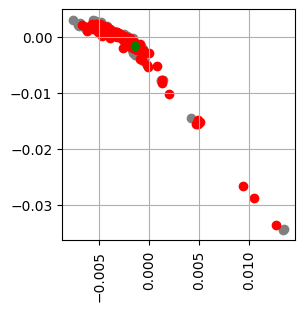

In [52]:
fig, ax = plt.subplots(figsize=(3, 3))
ax.scatter(
    projected_conds_train[:, 0],
    projected_conds_train[:, 1],
    label="train",
    color="grey",
)
ax.scatter(
    projected_conds_val[:, 0],
    projected_conds_val[:, 1],
    label="val",
    color="blue",
)
ax.scatter(
    projected_conds_gen[:, 0],
    projected_conds_gen[:, 1],
    label="val",
    color="red",
)
ax.scatter(
    projected_conds_gen[emin_loss_idx, 0][None],
    projected_conds_gen[emin_loss_idx, 1][None],
    label="val",
    color="green",
)
ax.grid(True)
ax.tick_params("x", rotation=90)

### Compute L2 distance in original concentration space.

In [53]:
D_espace_learned = cdist(samples, np.concatenate((unique_train_conds, unique_val_conds), axis=0))
D_espace_learned.shape

(150, 116)

### Plot distribution of distances.

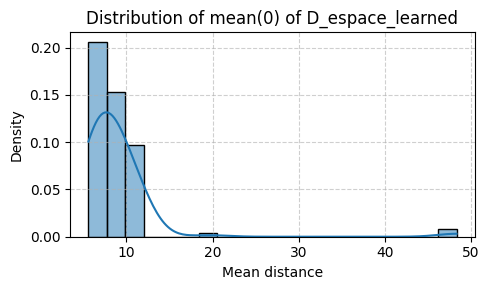

In [54]:
plt.figure(figsize=(5, 3))
sns.histplot(D_espace_learned.mean(0), bins=20, kde=True, stat="density")
plt.grid(True, linestyle="--", alpha=0.6)
plt.xlabel("Mean distance")
plt.ylabel("Density")
plt.title("Distribution of mean(0) of D_espace_learned")
plt.tight_layout()
plt.show()

### Retrieve closest neighbor in embedding space for best sample.

In [55]:
min_dist_idx = D_espace_learned[emin_loss_idx].argsort()[0].item()
nn_real_cond_best = unique_train_conds[min_dist_idx]

### Heatmap of NN condition.

<Axes: >

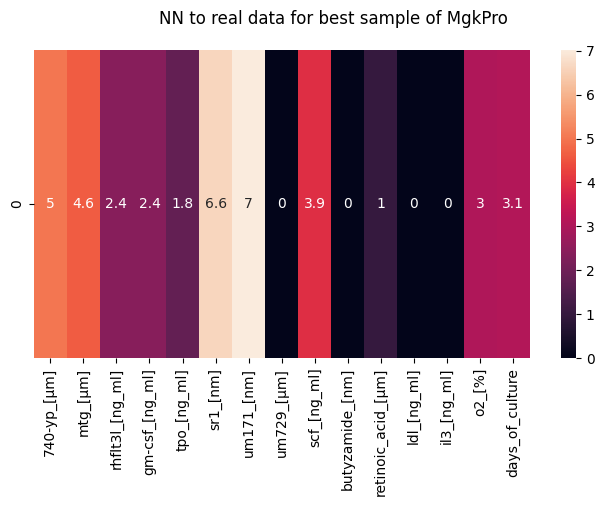

In [56]:
emin_loss_idx = np.argmin(loss_history[:, -1])
samples = np.maximum(traj[:, -1, :], 0)
fig, ax = plt.subplots(figsize=(8, 4), dpi=100)
fig.suptitle(f"NN to real data for best sample of {target_cell_type}")
sns.heatmap(nn_real_cond_best[None], annot=True, ax=ax, xticklabels=annotation_dict["protocol_columns"])

## Visualize cell type proportions.

### Displaying induced phenotype heatmap.

<Axes: >

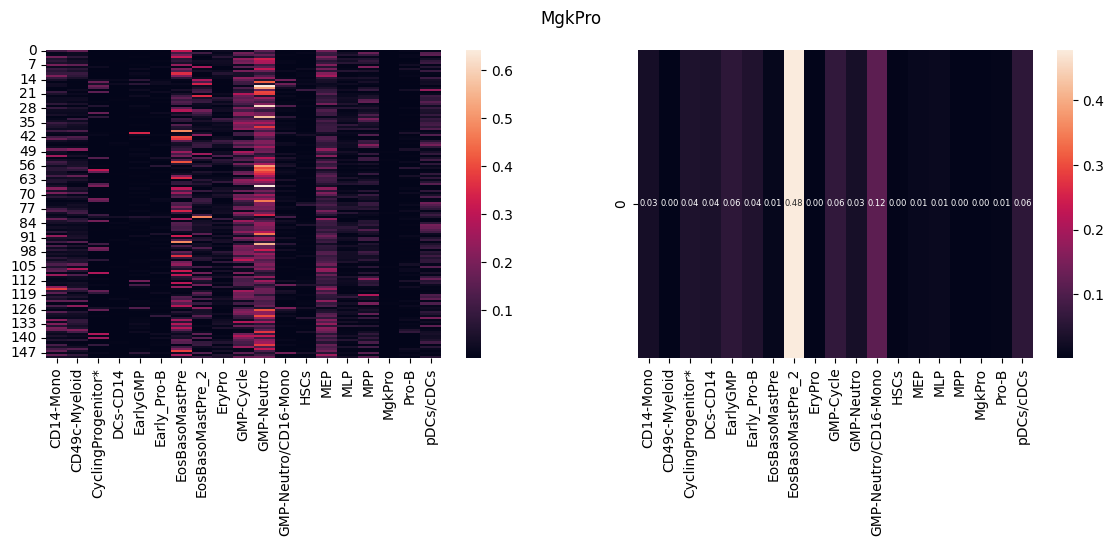

In [57]:
ct_probs = gen_ct_probs.mean(1)
samples = np.maximum(traj[:, -1, :], 0)
fig, ax = plt.subplots(1, 2, figsize=(14, 4), dpi=100)
fig.suptitle(target_cell_type)
sns.heatmap(ct_probs, annot=False, ax=ax[0], xticklabels=ct_le.classes_)
sns.heatmap(ct_probs[emin_loss_idx][None], annot=True, ax=ax[1], xticklabels=ct_le.classes_, fmt=".2f", annot_kws={"size": 6})

## Visualize generated cell states.

### Concatenate real and generated data.

In [69]:
# concatenate real and generated cell states.
loss = loss_history[:, -1]
emin_loss_idx = np.argsort(loss)[len(loss)//4]
# emin_loss_idx = np.argmin(loss_history[:, -1])
X = np.concatenate(
    (
        X_gen[emin_loss_idx],
        train_adata_phi.obsm[cell_state_rep],
        val_adata_phi.obsm[cell_state_rep]
    ),
    axis=0
)
X_channel = X[:, :-n_scatter_feats]
X_scatter = X[:, -n_scatter_feats:]

# concatenate predicted cell types for real and generated data
G = np.concatenate(
    (
        gen_ct_label[emin_loss_idx],
        G_label_train,
        G_label_val,
    ),
    axis=0
)
print(f"{X_channel.shape=}, {X_scatter.shape=}{G.shape}")

X_channel.shape=(100500, 21), X_scatter.shape=(100500, 6)(100500,)


### Create annotated data.

In [59]:
ct_adata = sc.AnnData(
    X=X_channel,
    obsm={"X_scatter": X_scatter},
    obs={
        "cell_type": G,
        "data_type": ["gen"]*X_gen[emin_loss_idx].shape[0] + \
            ["train"]*len(train_adata_phi) + ["val"]*len(val_adata_phi)
    },
    var=pd.DataFrame(index=train_adata_phi.var_names)
)
sc.pp.pca(ct_adata)
sc.pp.neighbors(ct_adata)
sc.tl.umap(ct_adata)
print(f"{ct_adata=}")


ct_adata=AnnData object with n_obs × n_vars = 100500 × 21
    obs: 'cell_type', 'data_type'
    uns: 'pca', 'neighbors', 'umap'
    obsm: 'X_scatter', 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'


In [71]:
classes = ct_le.classes_.tolist()
classes

['CD14-Mono',
 'CD49c-Myeloid',
 'CyclingProgenitor*',
 'DCs-CD14',
 'EarlyGMP',
 'Early_Pro-B',
 'EosBasoMastPre',
 'EosBasoMastPre_2',
 'EryPro',
 'GMP-Cycle',
 'GMP-Neutro',
 'GMP-Neutro/CD16-Mono',
 'HSCs',
 'MEP',
 'MLP',
 'MPP',
 'MgkPro',
 'Pro-B',
 'pDCs/cDCs']

### Visualize UMAP embeddings.

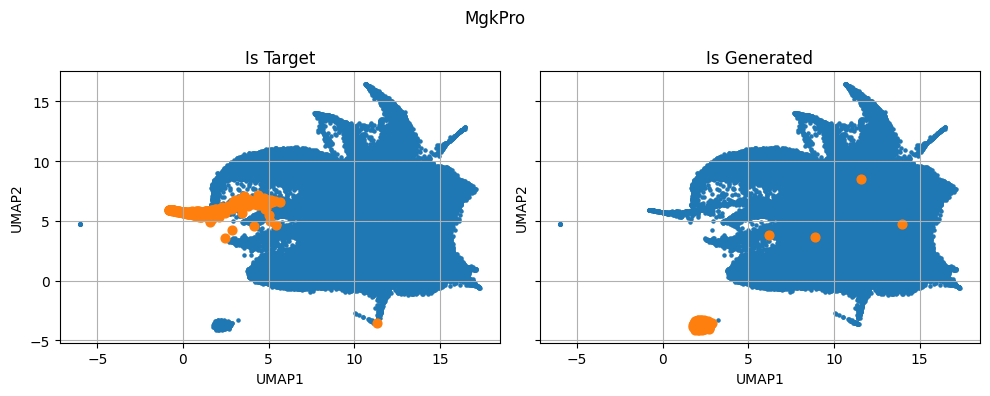

In [60]:
X_umap = ct_adata.obsm["X_umap"]
ct_mask = (ct_adata.obs["cell_type"] == target_cell_type) & (ct_adata.obs["data_type"] != "gen")
gen_mask = ct_adata.obs["data_type"] == "gen"
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharex=True, sharey=True)
fig.suptitle(target_cell_type)
axes[0].scatter(
    X_umap[:, 0],
    X_umap[:, 1],
    s=5,
    # alpha=0.2
)
axes[0].scatter(
    X_umap[ct_mask, 0],
    X_umap[ct_mask, 1],
    s=40,
    # alpha=0.9
)
axes[0].set_title(f"Is Target")
axes[0].grid(1)

axes[1].scatter(
    X_umap[:, 0],
    X_umap[:, 1],
    s=5,
    # alpha=0.2
)
axes[1].scatter(
    X_umap[gen_mask, 0],
    X_umap[gen_mask, 1],
    s=40,
    # alpha=0.9
)
axes[1].set_title("Is Generated")
axes[1].grid(1)

for ax in axes:
    ax.set_xlabel("UMAP1")
    ax.set_ylabel("UMAP2")

plt.tight_layout()
plt.show()

### Visualizing expression of (all) generated cells vs real HSCs.

/home/icb/lorenzo.consoli/miniconda3/envs/sc_exp_design/lib/python3.12/site-packages/anndata/_core/anndata.py:1138: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/home/icb/lorenzo.consoli/miniconda3/envs/sc_exp_design/lib/python3.12/site-packages/anndata/_core/anndata.py:1138: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/home/icb/lorenzo.consoli/miniconda3/envs/sc_exp_design/lib/python3.12/site-packages/anndata/_core/anndata.py:1138: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/home/icb/lorenzo.consoli/miniconda3/envs/sc_exp_design/lib/python3.12/site-packages/anndata/_core/anndata.py:1138: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


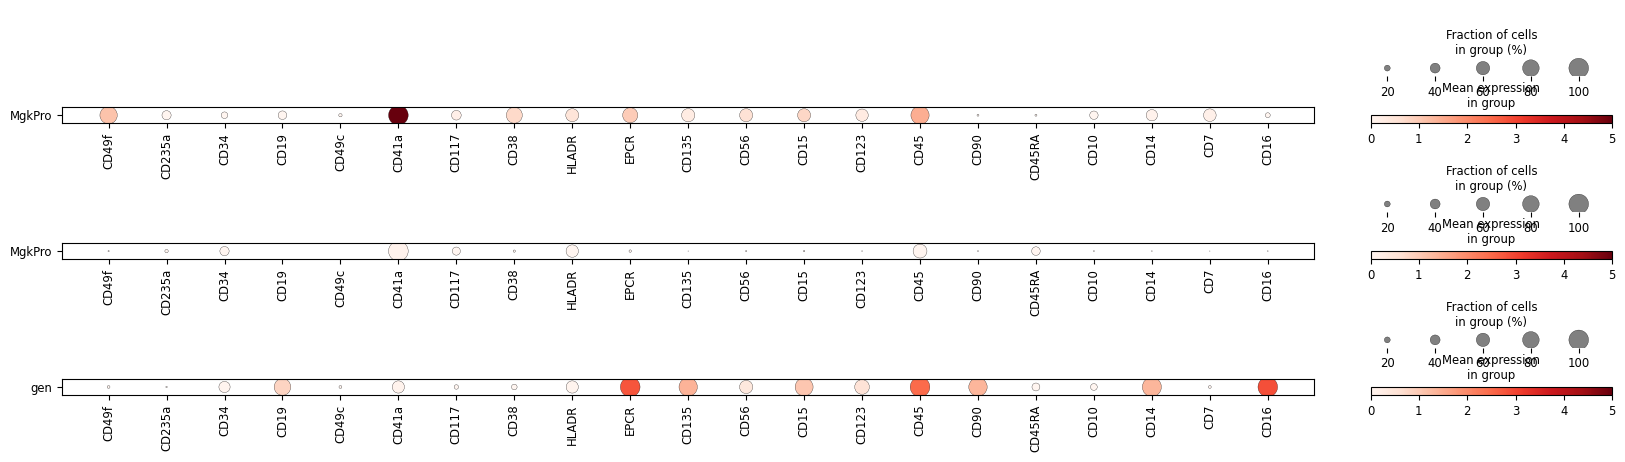

In [61]:
fig, ax = plt.subplots(3, 1, figsize=(20, 5))
vmin = 0; vmax = 5.0
sc.pl.dotplot(ct_adata[(ct_adata.obs.data_type != "gen") & (ct_adata.obs.cell_type == target_cell_type)], ct_adata.var_names, "cell_type", ax=ax[0], show=False, vmin=vmin, vmax=vmax)
sc.pl.dotplot(train_adata_g[(train_adata_g.obs.cell_type == target_cell_type)], train_adata_g.var_names, "cell_type", ax=ax[1], show=False, vmin=vmin, vmax=vmax)
sc.pl.dotplot(ct_adata[(ct_adata.obs.data_type == "gen")], ct_adata.var_names, "data_type", ax=ax[2], show=False, vmin=vmin, vmax=vmax)
fig.show()


## Population Distances.

### Computing e-dist between generated samples and cell type subpopulations (Channel Features).

In [62]:
edist_dict = defaultdict(list)
x_best = X_channel_gen[emin_loss_idx]
for ct in tqdm(classes):
    x_ct = train_adata_g[train_adata_g.obs.cell_type == ct].obsm["X_channel_standardized"]
    edist = compute_e_distance(x_best, x_ct)
    edist_dict["ct"].append(ct)
    edist_dict["edist"].append(edist)
edist_channel_df = pd.DataFrame(edist_dict).sort_values("edist", axis=0, ascending=False)
edist_channel_df

100%|██████████| 19/19 [00:03<00:00,  5.86it/s]


,ct,edist
16,MgkPro,714.030987
3,DCs-CD14,389.970307
11,GMP-Neutro/CD16-Mono,168.013379
2,CyclingProgenitor*,149.283727
17,Pro-B,148.005824
8,EryPro,134.847125
5,Early_Pro-B,114.514095
1,CD49c-Myeloid,102.052800
10,GMP-Neutro,100.519409
12,HSCs,100.198858


### Plotting values.

/tmp/ipykernel_3581558/2579984711.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


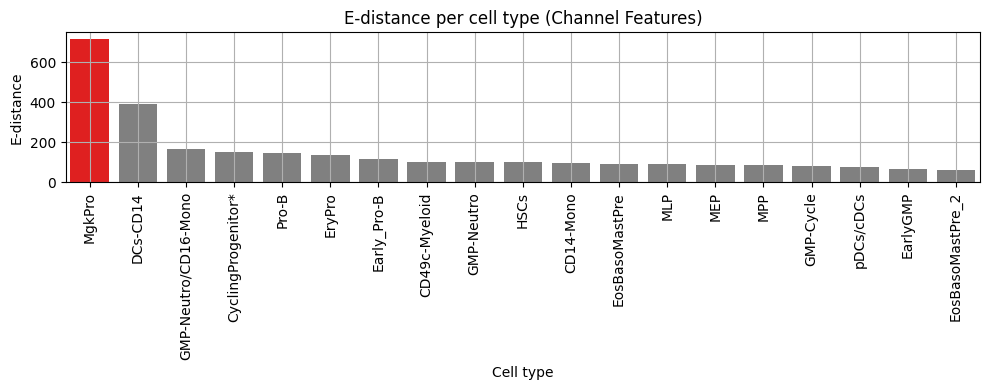

In [63]:
# Create a color column
edist_channel_df["color"] = edist_channel_df["ct"].apply(
    lambda x: "red" if x == target_cell_type else "gray"
)

plt.figure(figsize=(10, 4))
sns.barplot(
    data=edist_channel_df,
    x="ct",
    y="edist",
    palette=edist_channel_df["color"].tolist()
)

plt.grid(True)
plt.xticks(rotation=90)
plt.ylabel("E-distance")
plt.xlabel("Cell type")
plt.title("E-distance per cell type (Channel Features)")
plt.tight_layout()
plt.show()


### Computing e-dist between generated samples and cell type subpopulations (Scatter Features).

In [64]:
edist_dict = defaultdict(list)
x_best = X_scatter_gen[emin_loss_idx]
for ct in tqdm(classes):
    x_ct = train_adata_g[train_adata_g.obs.cell_type == ct].obsm["X_scatter_standardized"]
    edist = compute_e_distance(x_best, x_ct)
    edist_dict["ct"].append(ct)
    edist_dict["edist"].append(edist)
edist_scatter_df = pd.DataFrame(edist_dict).sort_values("edist", axis=0, ascending=False)
edist_scatter_df

100%|██████████| 19/19 [00:01<00:00,  9.81it/s]


,ct,edist
3,DCs-CD14,29.337714
5,Early_Pro-B,14.526105
17,Pro-B,14.049186
0,CD14-Mono,8.160213
14,MLP,7.852480
8,EryPro,7.083823
15,MPP,6.462506
13,MEP,6.109834
6,EosBasoMastPre,6.090716
12,HSCs,5.652287


### Plotting values.

/tmp/ipykernel_3581558/718491340.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


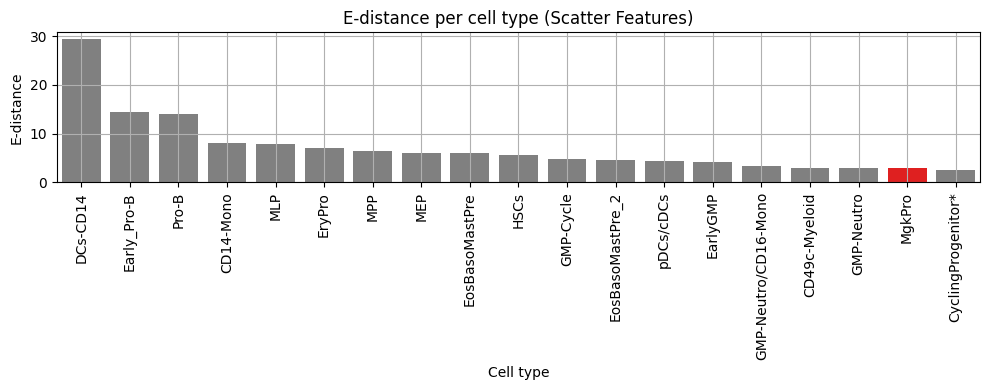

In [65]:
# Create a color column
edist_scatter_df["color"] = edist_scatter_df["ct"].apply(
    lambda x: "red" if x == target_cell_type else "gray"
)

plt.figure(figsize=(10, 4))
sns.barplot(
    data=edist_scatter_df,
    x="ct",
    y="edist",
    palette=edist_scatter_df["color"].tolist()
)

plt.grid(True)
plt.xticks(rotation=90)
plt.ylabel("E-distance")
plt.xlabel("Cell type")
plt.title("E-distance per cell type (Scatter Features)")
plt.tight_layout()
plt.show()


### Plotting cell states induced by nn condition to best sample.

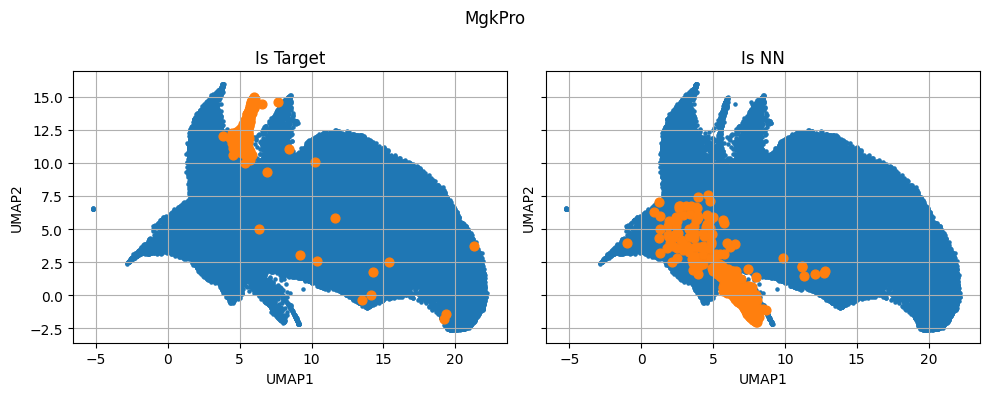

In [66]:
adata_phi.obs["cell_type"] = np.concatenate(
    (
        G_label_train,
        G_label_val,
    ),
    axis=0
)
X_umap = adata_phi.obsm["X_umap"]
ct_mask = (adata_phi.obs["cell_type"] == target_cell_type)
nn_mask = np.all(adata_phi.obsm["condition_concat"] == nn_real_cond_best, axis=1)
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharex=True, sharey=True)
fig.suptitle(target_cell_type)
axes[0].scatter(
    X_umap[:, 0],
    X_umap[:, 1],
    s=5,
    # alpha=0.2
)
axes[0].scatter(
    X_umap[ct_mask, 0],
    X_umap[ct_mask, 1],
    s=40,
    # alpha=0.9
)
axes[0].set_title(f"Is Target")
axes[0].grid(1)

axes[1].scatter(
    X_umap[:, 0],
    X_umap[:, 1],
    s=5,
    # alpha=0.2
)
axes[1].scatter(
    X_umap[nn_mask, 0],
    X_umap[nn_mask, 1],
    s=40,
    # alpha=0.9
)
axes[1].set_title("Is NN")
axes[1].grid(1)

for ax in axes:
    ax.set_xlabel("UMAP1")
    ax.set_ylabel("UMAP2")

plt.tight_layout()
plt.show()

## Comparing predictions with real conditions with the highest HSCs proportion.

### Iterate over the unique conditions and retrieve cell type proportions.

In [67]:
ct_counts_dict = {}
unique_conds =  np.concatenate((unique_train_conds, unique_val_conds))
for idx, cond in enumerate(unique_conds):
    cond_mask = np.all(adata_phi.obsm["condition_concat"] == cond, axis=1)
    cond_adata = adata_phi[cond_mask]
    counts = (cond_adata.obs.cell_type).value_counts().to_dict()
    ct_counts_dict[idx] = counts
ct_counts_df = pd.DataFrame(ct_counts_dict).T.fillna(0)
ct_counts_df = ct_counts_df/np.sum(ct_counts_df.values, axis=1, keepdims=True)
ct_counts_df.head()

,MPP,HSCs,pDCs/cDCs,GMP-Cycle,MEP,CD49c-Myeloid,EosBasoMastPre,EosBasoMastPre_2,Early_Pro-B,Pro-B,GMP-Neutro,EarlyGMP,MLP,MgkPro,EryPro,CD14-Mono,DCs-CD14,GMP-Neutro/CD16-Mono,CyclingProgenitor*
0,0.652632,0.115789,0.052632,0.042105,0.031579,0.031579,0.021053,0.010526,0.010526,0.010526,0.010526,0.010526,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0
1,0.526316,0.087719,0.192982,0.052632,0.052632,0.000000,0.017544,0.017544,0.035088,0.000000,0.000000,0.000000,0.017544,0.000000,0.000000,0.0,0.0,0.0,0.0
2,0.111111,0.055556,0.055556,0.333333,0.111111,0.000000,0.055556,0.000000,0.000000,0.000000,0.111111,0.000000,0.166667,0.000000,0.000000,0.0,0.0,0.0,0.0
3,0.583333,0.166667,0.000000,0.000000,0.250000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0
4,0.215470,0.011050,0.209945,0.033149,0.027624,0.000000,0.215470,0.049724,0.016575,0.005525,0.038674,0.000000,0.022099,0.082873,0.071823,0.0,0.0,0.0,0.0


### Boxplot of the proportions.

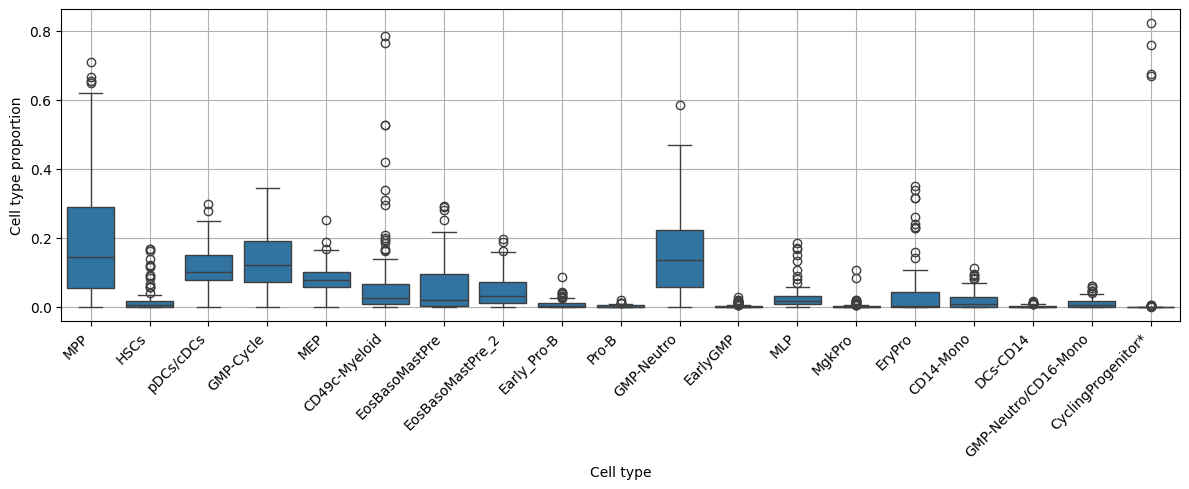

In [68]:
ct_long = ct_counts_df.reset_index(drop=True).melt(
    var_name="cell_type",
    value_name="proportion"
)

plt.figure(figsize=(12, 5))
sns.boxplot(
    data=ct_long,
    x="cell_type",
    y="proportion"
)

plt.xticks(rotation=45, ha="right")
plt.ylabel("Cell type proportion")
plt.xlabel("Cell type")
plt.tight_layout()
plt.grid(1)
plt.show()


### Retrieving conditioning inducing highest proportion of cell types.

<Axes: >

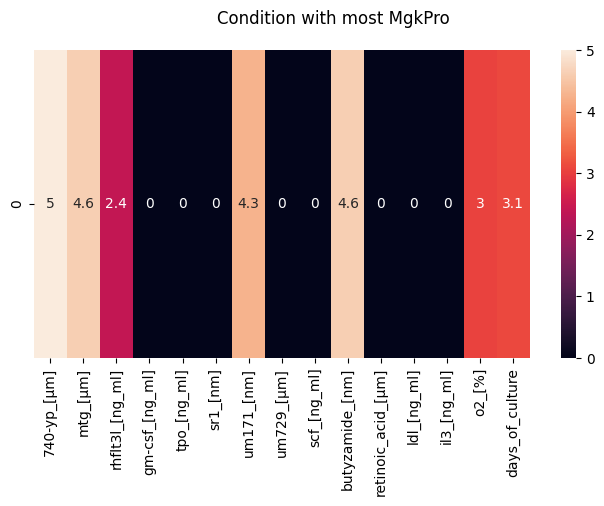

In [ ]:
cond_hsc_max = unique_conds[np.argmax(ct_counts_df.loc[:, target_cell_type])][None]
fig, ax = plt.subplots(figsize=(8, 4), dpi=100)
fig.suptitle(f"Condition with most {target_cell_type}")
sns.heatmap(cond_hsc_max, annot=True, ax=ax, xticklabels=annotation_dict["protocol_columns"])